In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [98]:
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

In [99]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [101]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [102]:
df.shape

(5110, 12)

In [103]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [104]:
df.duplicated().sum()

np.int64(0)

In [105]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [106]:
num_col = df.select_dtypes(include='number').columns.drop('stroke')
cat_col = df.select_dtypes(include='object').columns
print(f"Numerical columns : {num_col}")
print(f"Categorical columns : {cat_col}")

Numerical columns : Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi'],
      dtype='object')
Categorical columns : Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


### EDA

<Axes: xlabel='stroke', ylabel='count'>

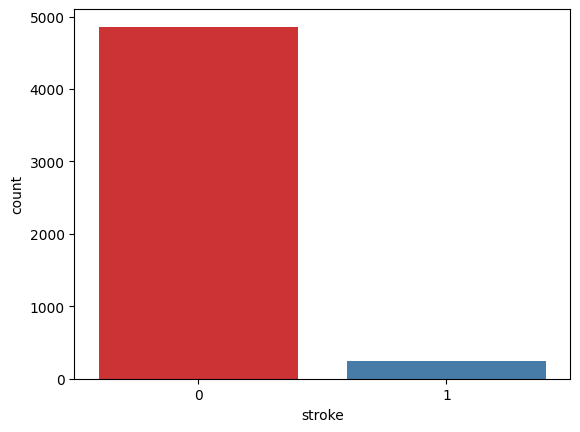

In [107]:
sns.countplot(x='stroke',data=df,palette='Set1')

<Axes: xlabel='bmi', ylabel='Count'>

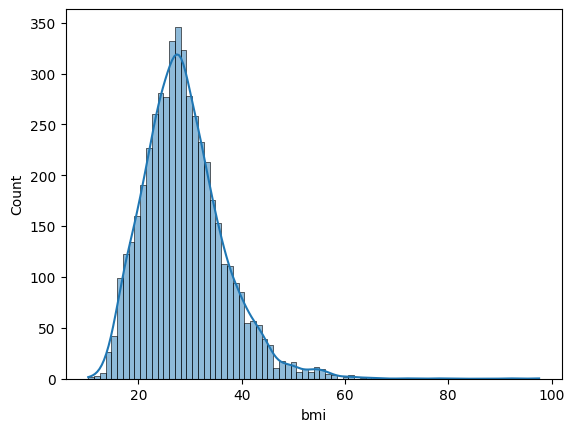

In [108]:
sns.histplot(x='bmi',data=df,kde=True)

<Axes: xlabel='stroke', ylabel='age'>

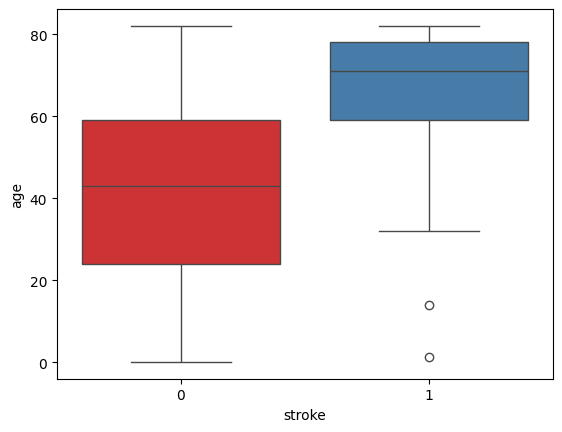

In [109]:
sns.boxplot(x='stroke',y='age',data=df,palette='Set1')

<Axes: xlabel='stroke', ylabel='bmi'>

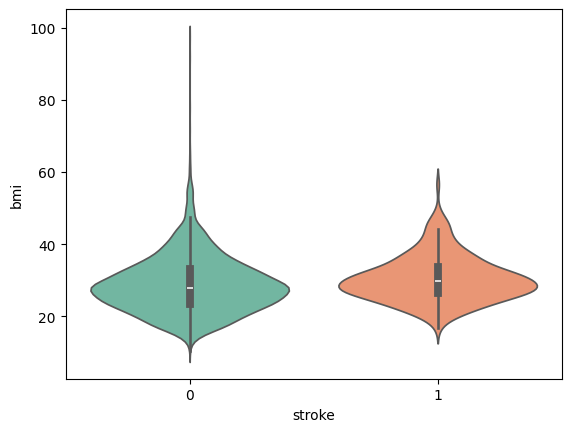

In [110]:
sns.violinplot(x='stroke',y='bmi',data=df,palette='Set2')

<Axes: xlabel='gender', ylabel='count'>

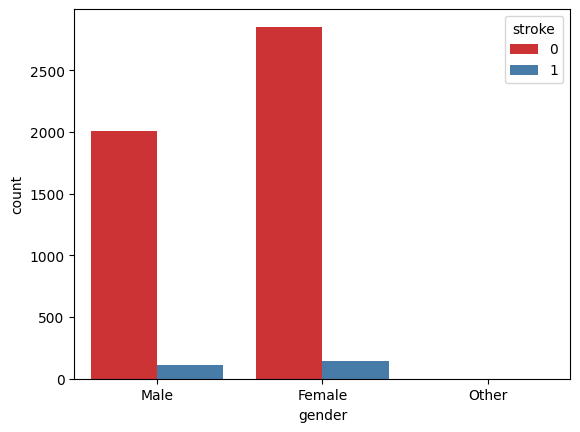

In [111]:
sns.countplot(x='gender',hue='stroke',data=df,palette='Set1')

<Axes: xlabel='age', ylabel='bmi'>

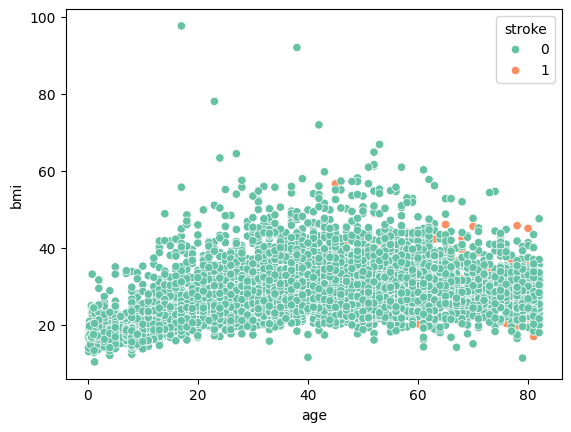

In [112]:
sns.scatterplot(x='age',y='bmi',hue='stroke',data=df,palette='Set2')

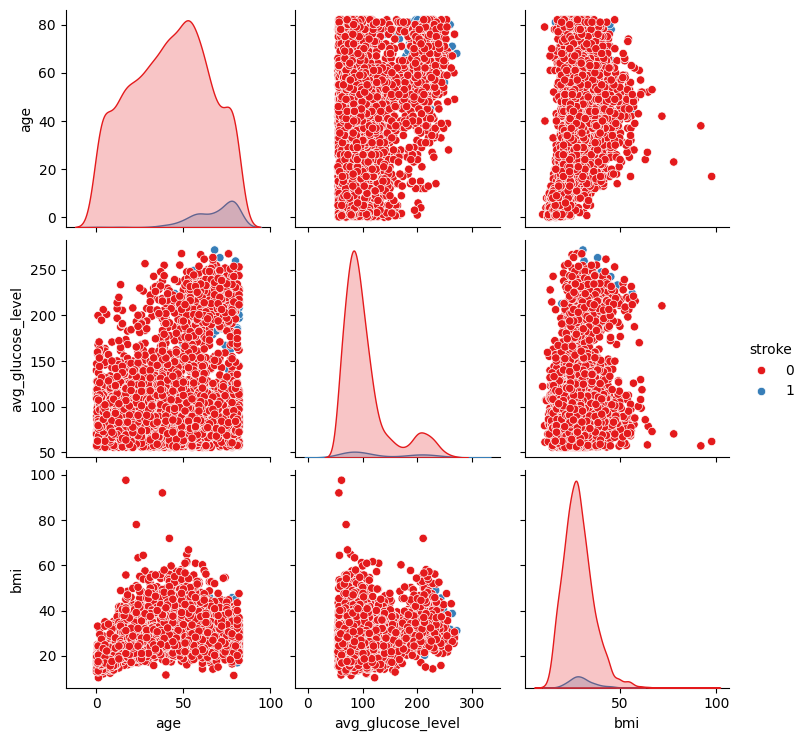

In [113]:
sns.pairplot(df[['age','avg_glucose_level','bmi','stroke']],hue='stroke',palette='Set1')

<Axes: >

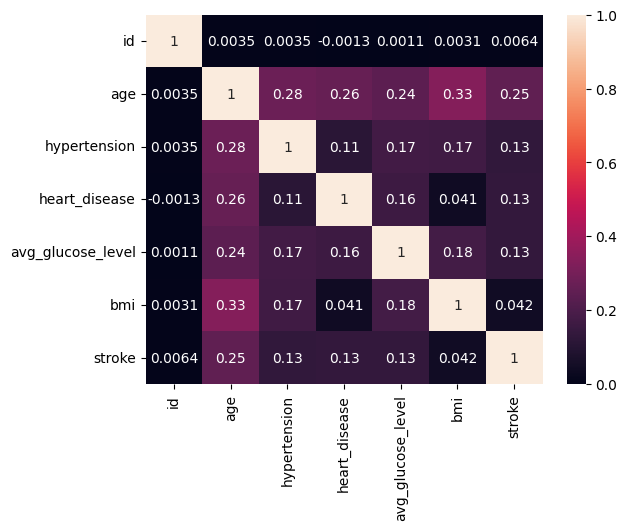

In [114]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [115]:
X = df.drop('stroke',axis=1)
y = df['stroke']

In [116]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

In [118]:
# PIPELINES
num_pipeline = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [119]:
# COLUMNTRANSFORMER
preprocessor = ColumnTransformer(
    transformers=[
        ('num',num_pipeline,num_col),
        ('cat',cat_pipeline,cat_col)
    ]
)

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [139]:
# LogisticRegression_pipeline = Pipeline(
#     steps=[
#         ('preprocessor',preprocessor),
#         ('classifier',LogisticRegression())
#     ]
# )

# DecisionTreeRegressor_pipeline = Pipeline(
#     steps=[
#         ('preprocessor',preprocessor),
#         ('classifier',DecisionTreeRegressor())
#     ]
# )

# RandomForest_pipeline = Pipeline(
#     steps=[
#         ('preprocessor',preprocessor),
#         ('classifier',RandomForestClassifier())
#     ]
# )

In [140]:
# LogisticRegression_pipeline.fit(X_train,y_train)


In [141]:
# lg_y_pred = LogisticRegression_pipeline.predict(X_test)
# lg_y_pred

In [142]:
# print("Accuracy :", accuracy_score(y_test, lg_y_pred))
# print("Precision:", precision_score(y_test, lg_y_pred))
# print("Recall   :", recall_score(y_test, lg_y_pred))
# print("F1 Score :", f1_score(y_test, lg_y_pred))

In [143]:
# DecisionTreeRegressor_pipeline.fit(X_train,y_train)

In [144]:
# dt_y_pred = DecisionTreeRegressor_pipeline.predict(X_test)
# dt_y_pred

In [145]:
# print(f"Accuracy : {accuracy_score(y_test,dt_y_pred)}")
# print(f"Precision : {precision_score(y_test,dt_y_pred)}")
# print(f"Recall : {recall_score(y_test,dt_y_pred)}")
# print(f"F1 Score : {f1_score(y_test,dt_y_pred)}")

In [146]:
# RandomForest_pipeline.fit(X_train,y_train)

In [147]:
# rf_y_pred = RandomForest_pipeline.predict(X_test)
# rf_y_pred

In [148]:
# print(f"Accuracy : {accuracy_score(y_test,rf_y_pred)}")
# print(f"Precision : {precision_score(y_test,rf_y_pred)}")
# print(f"Recall : {recall_score(y_test,rf_y_pred)}")
# print(f"F1 Score : {f1_score(y_test,rf_y_pred)}")

In [149]:
# from sklearn.metrics import roc_auc_score
# y_prob = LogisticRegression_pipeline.predict_proba(X_test)[:,1]
# roc_auc_score(y_test,y_prob)

In [150]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42)
}

In [155]:
model_performance = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    model_performance.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

performance_df = pd.DataFrame(model_performance)
display(performance_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.745597,0.167785,0.806452,0.277778,0.851445
1,Decision Tree,0.911937,0.208333,0.161290,0.181818,0.560853
2,Random Forest,0.939335,0.000000,0.000000,0.000000,0.813382


In [157]:
## Randomized search cv
from sklearn.model_selection import RandomizedSearchCV
RandomForest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

# Hyperparameter
param_space = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt', 'log2'],
    'model__bootstrap':[True,False]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=RandomForest_pipeline,
    param_distributions=param_space,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs = -1
)

# train
random_search.fit(X_train, y_train)

# best model
best_model = random_search.best_estimator_

# predict
y_pred = best_model.predict(X_test)

In [160]:
print("Best parameter: ")
print(random_search.best_params_)
print("Best score: ", random_search.best_score_)

Best parameter: 
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20, 'model__bootstrap': True}
Best score:  0.9540120842847438


In [161]:
print("Best CV F1 Score:")
print(random_search.best_score_)

Best CV F1 Score:
0.9540120842847438


In [163]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

y_prob = best_model.predict_proba(X_test)[:, 1]
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9373776908023483
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.820950940860215

Confusion Matrix
[[958   2]
 [ 62   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022

